# 🧊 Projeto Fatorial 2³ com Replicações — Consenso entre LLMs

Extensão do projeto 2² adicionando um **terceiro fator: tamanho do texto**.
O consenso continua sendo construído **reutilizando a mesma máquina do notebook
`analise_consenso_llms_extra.ipynb`** (`ConsensusCalculator` +
`ConsensusEvaluator`).

**Fatores**

| Fator | Variável | -1 | +1 |
|-------|----------|----|----|
| **Domínio**         | **B** | MovieReview (geral)   | Books (técnico)     |
| **Consenso**        | **C** | Maioria simples (2×1) | Unanimidade (3×0)   |
| **Tamanho do texto**| **D** | Curto                 | Longo               |

O **consenso (C)** é o **padrão de concordância** de cada exemplo (partição):
**2×1** = exatamente 2 dos 3 modelos concordam (`most_common_count == 2`);
**3×0** = os 3 concordam (`most_common_count == 3`). O fator **D** usa um **corte
na mediana de `text_len` dentro de cada domínio** (ortogonal a B e C). Cada
combinação tem **5 replicações**.

Projeto **2³ completo com replicação** ⇒ 2³ × 5 = **40 observações**.
Efeitos: principais (B, C, D) e interações (BC, BD, CD, BCD).
Respostas: **F1 Macro** e **Acurácia**.

> ⚠️ Como no 2², o erro experimental é minúsculo (réplicas quase
> determinísticas) ⇒ quase tudo sai significativo. **Interprete pelo tamanho do
> efeito (2q) e pela % de variação**, não pelo p-valor.

> Os modelos individuais **não** entram no projeto fatorial — servem apenas
> para benchmark posterior.


## 1) Setup e configuração

In [1]:
import os
import sys
import glob
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
)
from loguru import logger

# Localiza a raiz do projeto (a que contém data/results) e a coloca no path
ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Reutiliza a MESMA máquina de consenso do notebook analise_consenso_llms_extra
from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()  # silencia os logs verbosos do consenso (rodamos muitas vezes)

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"] = 110

MODELS = ["deepseek-r1-8b", "qwen3-8b", "llama3.1-8b"]
CONS_COLS = [f"{m}_consensus" for m in MODELS]

DATASETS = ["movie_review", "books"]   # B = -1 (movie), +1 (books)
N_REPS = 5                              # nº de replicações por dataset
INVALID = -1                            # código de predição/label inválida

RESULTS_DIR = ROOT / "data" / "results"
print("Raiz do projeto:", ROOT)
print("Resultados em  :", RESULTS_DIR)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation
Resultados em  : C:\Users\gabri\Documents\GitHub\llm-annotation\data\results


## 2) Selecionar as 5 réplicas de cada dataset

As replicações são as **5 últimas pastas** (ordem cronológica pelo nome) de cada
dataset que contenham `annotations.csv`.

In [2]:
def last_n_replication_folders(dataset, n=N_REPS):
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
    )
    chosen = folders[-n:]
    if len(chosen) < n:
        raise ValueError(f"{dataset}: encontrei só {len(chosen)} pastas (esperado {n}).")
    return chosen


REPLICATION_FOLDERS = {ds: last_n_replication_folders(ds) for ds in DATASETS}

for ds, folders in REPLICATION_FOLDERS.items():
    print(f"\n== {ds} ==")
    for i, f in enumerate(folders, start=1):
        print(f"  rep{i}: {os.path.basename(os.path.normpath(f))}")


== movie_review ==
  rep1: 2026-04-09_13-17-23
  rep2: 2026-05-17_14-44-16
  rep3: 2026-05-17_21-51-31
  rep4: 2026-05-18_06-14-02
  rep5: 2026-05-18_22-29-27

== books ==
  rep1: 2026-04-09_13-21-37
  rep2: 2026-05-20_21-44-17
  rep3: 2026-05-23_00-20-50
  rep4: 2026-05-24_20-47-50
  rep5: 2026-05-26_18-26-27


## 3) Consenso (partição por concordância) + corte por tamanho do texto

Rodamos o `ConsensusCalculator` (`majority_vote`, threshold 0.8) **uma vez** por
réplica e classificamos cada exemplo pelo **padrão de concordância** dos 3 modelos:

- **3×0** (unânime) ⇔ `most_common_count == 3`;
- **2×1** (maioria simples) ⇔ `most_common_count == 2`.

Aplicamos a **mesma limpeza** (descarta `ground_truth` inválido e
`resolved_annotation == -1`) e **exigimos maioria** (`most_common_count >= 2`,
descarta as 3 predições distintas). Assim **2×1 e 3×0 particionam** os exemplos.

O fator **D (tamanho)** vem de um **corte na mediana de `text_len` por domínio**
(a mediana é a mesma em todas as réplicas, pois os textos são os mesmos):

- **Curto** = `text_len <= mediana` (D = -1)
- **Longo** = `text_len >  mediana` (D = +1)

In [3]:
CONSENSOS = {"2x1": 2, "3x0": 3}   # padrão de concordância -> most_common_count


def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)


def quality_metrics(y_true, y_pred):
    return {
        "accuracy":        accuracy_score(y_true, y_pred),
        "f1_macro":        f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":    recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def consensus_universe(df_raw, categories, output_dir):
    """Universo válido COM maioria (most_common_count>=2), com text_len/resolved.
    most_common_count == 3 -> unânime (3x0) ; == 2 -> maioria simples (2x1)."""
    calculator = ConsensusCalculator(consensus_threshold=0.8, default_strategy="majority_vote")
    evaluator = ConsensusEvaluator(categories=categories, calculator=calculator, output_dir=output_dir)
    sub = df_raw[["text_id", "text", "text_len", "ground_truth"] + CONS_COLS].copy()
    dfc = evaluator.compute_consensus(sub)
    dfc = dfc[(dfc["ground_truth"] != INVALID)
              & (dfc["resolved_annotation"] != INVALID)
              & (dfc["most_common_count"] >= 2)]
    return dfc

## 4) Métricas por célula (dataset × réplica × consenso × tamanho)

Para cada célula calculamos **Accuracy, F1 Macro, Precision/Recall Macro** no
subconjunto definido pelo **padrão de concordância (2×1/3×0)** e pela **faixa de
tamanho**. A `coverage` = fração do universo naquela célula; as 4 células
(consenso × tamanho) de cada réplica **somam 100%** (partição).

In [4]:
LEN_LEVELS = {"curto": -1, "longo": +1}


def split_by_length(df, mediana, nivel):
    return df[df["text_len"] <= mediana] if nivel == "curto" else df[df["text_len"] > mediana]


rows = []
for ds in DATASETS:
    for rep_idx, folder in enumerate(REPLICATION_FOLDERS[ds], start=1):
        df_raw = pd.read_csv(os.path.join(folder, "annotations.csv"))
        categories = get_categories(df_raw)
        mediana = df_raw.loc[df_raw["ground_truth"] != INVALID, "text_len"].median()
        universe = consensus_universe(df_raw, categories, folder)   # 1 cálculo por réplica
        total = len(universe)
        for consenso, need in CONSENSOS.items():
            uni_c = universe[universe["most_common_count"] == need]   # partição do consenso
            for nivel in LEN_LEVELS:
                cell = split_by_length(uni_c, mediana, nivel)
                y_true = cell["ground_truth"].astype(int)
                y_pred = cell["resolved_annotation"].astype(int)
                m = quality_metrics(y_true, y_pred)
                rows.append({
                    "dataset": ds, "replica": rep_idx, "consenso": consenso,
                    "tamanho": nivel, "mediana_len": mediana,
                    "coverage": len(cell) / total if total else 0.0,  # fração do universo
                    "n_total": total, "n_covered": len(cell),
                    **m,
                })

df_results = pd.DataFrame(rows)
print("Linhas:", len(df_results), "(esperado 2×2×2×5 = 40)")
# checagem da partição: soma das 4 células (consenso×tamanho) = total, por (dataset, réplica)
chk = df_results.groupby(["dataset", "replica"]).agg(
    soma=("n_covered", "sum"), total=("n_total", "first")).reset_index()
print("Partição OK?", bool((chk["soma"] == chk["total"]).all()))
df_results

Linhas: 40 (esperado 2×2×2×5 = 40)
Partição OK? True


,dataset,replica,consenso,tamanho,mediana_len,coverage,n_total,n_covered,accuracy,f1_macro,precision_macro,recall_macro
0,movie_review,1,2x1,curto,112.0000,0.0494,10653,526,0.6350,0.6342,0.6350,0.6343
1,movie_review,1,2x1,longo,112.0000,0.0516,10653,550,0.6255,0.6251,0.6254,0.6257
2,movie_review,1,3x0,curto,112.0000,0.4539,10653,4835,0.9477,0.9476,0.9480,0.9475
3,movie_review,1,3x0,longo,112.0000,0.4451,10653,4742,0.9431,0.9431,0.9431,0.9432
4,movie_review,2,2x1,curto,112.0000,0.0481,10649,512,0.6387,0.6381,0.6382,0.6380
5,movie_review,2,2x1,longo,112.0000,0.0484,10649,515,0.6078,0.6061,0.6064,0.6074
6,movie_review,2,3x0,curto,112.0000,0.4549,10649,4844,0.9472,0.9471,0.9475,0.9469
7,movie_review,2,3x0,longo,112.0000,0.4487,10649,4778,0.9410,0.9410,0.9410,0.9411
8,movie_review,3,2x1,curto,112.0000,0.0502,10650,535,0.6430,0.6408,0.6432,0.6411
9,movie_review,3,2x1,longo,112.0000,0.0507,10650,540,0.6019,0.6012,0.6014,0.6018


### Tabela 1 — Resultados por célula

In [5]:
cols_show = ["dataset", "consenso", "tamanho", "replica", "f1_macro", "accuracy",
             "precision_macro", "recall_macro", "coverage", "n_covered", "n_total"]
tabela1 = (df_results[cols_show]
           .sort_values(["dataset", "consenso", "tamanho", "replica"])
           .reset_index(drop=True))
tabela1

,dataset,consenso,tamanho,replica,f1_macro,accuracy,precision_macro,recall_macro,coverage,n_covered,n_total
0,books,2x1,curto,1,0.4904,0.5173,0.5442,0.5093,0.1282,4230,33005
1,books,2x1,curto,2,0.4752,0.5021,0.5230,0.4965,0.1305,4312,33034
2,books,2x1,curto,3,0.5006,0.5246,0.5500,0.5182,0.1307,4316,33029
3,books,2x1,curto,4,0.4781,0.5065,0.5331,0.4949,0.1282,4235,33029
4,books,2x1,curto,5,0.4783,0.5096,0.5284,0.5043,0.1308,4321,33036
5,books,2x1,longo,1,0.5515,0.5261,0.6410,0.5266,0.1201,3965,33005
6,books,2x1,longo,2,0.5537,0.5292,0.6386,0.5328,0.1206,3983,33034
7,books,2x1,longo,3,0.5356,0.5128,0.6272,0.5090,0.1222,4035,33029
8,books,2x1,longo,4,0.5356,0.5124,0.6251,0.5142,0.1185,3915,33029
9,books,2x1,longo,5,0.5581,0.5265,0.6401,0.5369,0.1213,4006,33036


## 5) Codificação do projeto fatorial 2³

| Fator | Variável | Mapa |
|-------|----------|------|
| Domínio  | **B** | MovieReview = -1, Books = +1 |
| Consenso | **C** | 2×1 = -1, 3×0 = +1 |
| Tamanho  | **D** | curto = -1, longo = +1 |

Tratamento rotulado pelas letras minúsculas dos fatores em nível +1
(`(1)` quando todos em -1): `b, c, d, bc, bd, cd, bcd`.

In [6]:
B_MAP = {"movie_review": -1, "books": +1}
C_MAP = {"2x1": -1, "3x0": +1}
D_MAP = {"curto": -1, "longo": +1}

df_results["B"] = df_results["dataset"].map(B_MAP)
df_results["C"] = df_results["consenso"].map(C_MAP)
df_results["D"] = df_results["tamanho"].map(D_MAP)


def treat_label(b, c, d):
    s = "".join(n for n, v in [("b", b), ("c", c), ("d", d)] if v == 1)
    return s if s else "(1)"


df_results["tratamento"] = [treat_label(b, c, d)
                            for b, c, d in zip(df_results["B"], df_results["C"], df_results["D"])]
df_results[["dataset", "consenso", "tamanho", "tratamento", "B", "C", "D",
            "f1_macro", "accuracy"]].head(40)

,dataset,consenso,tamanho,tratamento,B,C,D,f1_macro,accuracy
0,movie_review,2x1,curto,(1),-1,-1,-1,0.6342,0.6350
1,movie_review,2x1,longo,d,-1,-1,1,0.6251,0.6255
2,movie_review,3x0,curto,c,-1,1,-1,0.9476,0.9477
3,movie_review,3x0,longo,cd,-1,1,1,0.9431,0.9431
4,movie_review,2x1,curto,(1),-1,-1,-1,0.6381,0.6387
5,movie_review,2x1,longo,d,-1,-1,1,0.6061,0.6078
6,movie_review,3x0,curto,c,-1,1,-1,0.9471,0.9472
7,movie_review,3x0,longo,cd,-1,1,1,0.9410,0.9410
8,movie_review,2x1,curto,(1),-1,-1,-1,0.6408,0.6430
9,movie_review,2x1,longo,d,-1,-1,1,0.6012,0.6019


## 6) Função genérica de análise fatorial 2^k com replicação

Modelo: $y = q_0 + \sum_i q_i x_i + \sum_{i<j} q_{ij} x_i x_j + \dots + e$

- $q_{efeito} = \dfrac{\sum (x\,\text{do contraste})\cdot y}{N}$, com $N = 2^k r = 40$
- **Efeito** $= 2 q$ ; $SS = N q^2$ ; $SST = \sum (y-\bar{y})^2$
- $SSE = SST - \sum SS_{efeitos}$ ; $g.l._{erro} = 2^k(r-1) = 32$
- $s_e^2 = SSE/g.l._{erro}$ ; $s_q = \sqrt{s_e^2/N}$
- $t = q/s_q$ ; IC: $q \pm t_{1-\alpha/2;\,g.l.}\, s_q$

In [7]:
def factorial_2k_analysis(data, response, factors, r=N_REPS, alpha=0.05):
    """Análise fatorial 2^k completa (todos os efeitos principais e interações)."""
    d = data.copy()
    y = d[response].to_numpy(dtype=float)
    k = len(factors)
    N = (2 ** k) * r
    assert len(d) == N, f"Esperado {N} observações, obtidas {len(d)}"

    # ---- colunas de contraste de cada efeito (produtos dos fatores) ---
    effect_names, effect_cols = [], {}
    for size in range(1, k + 1):
        for combo in combinations(factors, size):
            name = "".join(combo)
            col = np.ones(N)
            for f in combo:
                col = col * d[f].to_numpy(dtype=float)
            effect_names.append(name)
            effect_cols[name] = col

    # ---- médias por tratamento --------------------------------------
    means = (d.groupby(["tratamento"] + factors)[response]
               .agg(media="mean", std="std", var="var", n="count")
               .reset_index())

    # ---- q, SS e significância --------------------------------------
    q0 = y.mean()
    SST = ((y - y.mean()) ** 2).sum()
    df_err = (2 ** k) * (r - 1)

    qs, SS = {}, {}
    for name in effect_names:
        q = (effect_cols[name] * y).sum() / N
        qs[name] = q
        SS[name] = N * q ** 2

    SSE = SST - sum(SS.values())
    s2e = SSE / df_err
    s_q = np.sqrt(s2e / N)
    t_crit = stats.t.ppf(1 - alpha / 2, df_err)

    sig_rows = []
    for name in effect_names:
        q, ss = qs[name], SS[name]
        t_val = q / s_q if s_q > 0 else np.nan
        p_val = 2 * stats.t.sf(abs(t_val), df_err) if s_q > 0 else np.nan
        sig_rows.append({
            "efeito": name,
            "q": q,
            "efeito (2q)": 2 * q,
            "IC q low":  q - t_crit * s_q,
            "IC q high": q + t_crit * s_q,
            "t": t_val,
            "p_value": p_val,
            "signif. (5%)": bool(p_val < alpha) if not np.isnan(p_val) else False,
            "SS": ss,
            "% variação": 100 * ss / SST if SST > 0 else np.nan,
        })
    significance = pd.DataFrame(sig_rows)

    effects = significance[["efeito", "q", "efeito (2q)", "% variação"]].copy()

    ss_table = pd.DataFrame(
        [{"componente": n, "SS": SS[n], "g.l.": 1, "% variação": 100 * SS[n] / SST}
         for n in effect_names]
        + [{"componente": "Erro", "SS": SSE, "g.l.": df_err, "% variação": 100 * SSE / SST},
           {"componente": "Total", "SS": SST, "g.l.": N - 1, "% variação": 100.0}]
    )

    return {
        "response": response, "means": means, "effects": effects,
        "significance": significance, "ss_table": ss_table,
        "q0": q0, "s2e": s2e, "s_q": s_q, "SSE": SSE, "SST": SST,
        "df_err": df_err, "t_crit": t_crit, "N": N,
    }


FACTORS = ["B", "C", "D"]

## 7) Funções de gráfico (efeitos principais e interações)

In [8]:
LAB = {
    "B": {-1: "MovieReview", +1: "Books"},
    "C": {-1: "Maioria (2×1)", +1: "Unanimidade (3×0)"},
    "D": {-1: "Curto", +1: "Longo"},
}
FACTOR_NAME = {"B": "Domínio", "C": "Consenso", "D": "Tamanho"}


def main_effect_plot(data, factor, response, ax):
    g = data.groupby(factor)[response].mean()
    xs = sorted(g.index)
    ax.plot([LAB[factor][x] for x in xs], [g[x] for x in xs], "o-", lw=2, ms=9, color="#2c6fbb")
    for x in xs:
        ax.annotate(f"{g[x]:.4f}", (LAB[factor][x], g[x]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
    ax.set_title(f"Efeito principal — {FACTOR_NAME[factor]} ({factor})")
    ax.set_ylabel(f"Média de {response}")
    ax.grid(alpha=0.3)


def interaction_plot(data, f1, f2, response, ax):
    colors = {-1: "#2c6fbb", +1: "#d1495b"}
    for lvl in (-1, +1):
        sub = data[data[f2] == lvl].groupby(f1)[response].mean()
        xs = sorted(sub.index)
        ax.plot([LAB[f1][x] for x in xs], [sub[x] for x in xs], "o-", lw=2, ms=9,
                color=colors[lvl], label=f"{FACTOR_NAME[f2]}: {LAB[f2][lvl]}")
    ax.set_title(f"Interação {FACTOR_NAME[f1]} × {FACTOR_NAME[f2]} ({f1}{f2})")
    ax.set_ylabel(f"Média de {response}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


def plot_factorial(data, response):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    for ax, f in zip(axes[0], FACTORS):
        main_effect_plot(data, f, response, ax)
    for ax, (f1, f2) in zip(axes[1], [("B", "C"), ("B", "D"), ("C", "D")]):
        interaction_plot(data, f1, f2, response, ax)
    fig.suptitle(f"Projeto fatorial 2³ — resposta: {response}", fontsize=13)
    plt.tight_layout()
    plt.show()

## 8) Premissas do modelo fatorial 2³ — **verificadas antes da análise**

Antes de confiar nos efeitos/p-valores, checamos os pressupostos sobre os resíduos
$e_{ij} = y_{ij} - \bar{y}_{\text{tratamento}}$ (**independentes, normais, variância
constante**):

- **Normalidade** — Shapiro-Wilk + histograma + QQ-plot dos resíduos.
- **Homoscedasticidade** — **Levene** (mediana, robusto) e **Bartlett** entre os 8
  tratamentos + gráfico **resíduos × ajustados** (procurar funil/padrão).
- **Independência** — **Durbin-Watson** (≈ 2 ⇒ sem autocorrelação).

Avaliado para **F1-macro** e **Acurácia**. Se a variância não for constante,
retestamos após **transformação logit** da resposta.

Testes de premissas (resíduos do fatorial 2³):


,resposta,Shapiro_W,Shapiro_p,normal_ok(5%),Levene_p,Bartlett_p,homoced_ok(5%),Durbin_Watson
0,f1_macro,0.9333,0.0207,False,0.0594,0.0000,True,1.8080
1,accuracy,0.9187,0.0070,False,0.0235,0.0000,False,1.7339


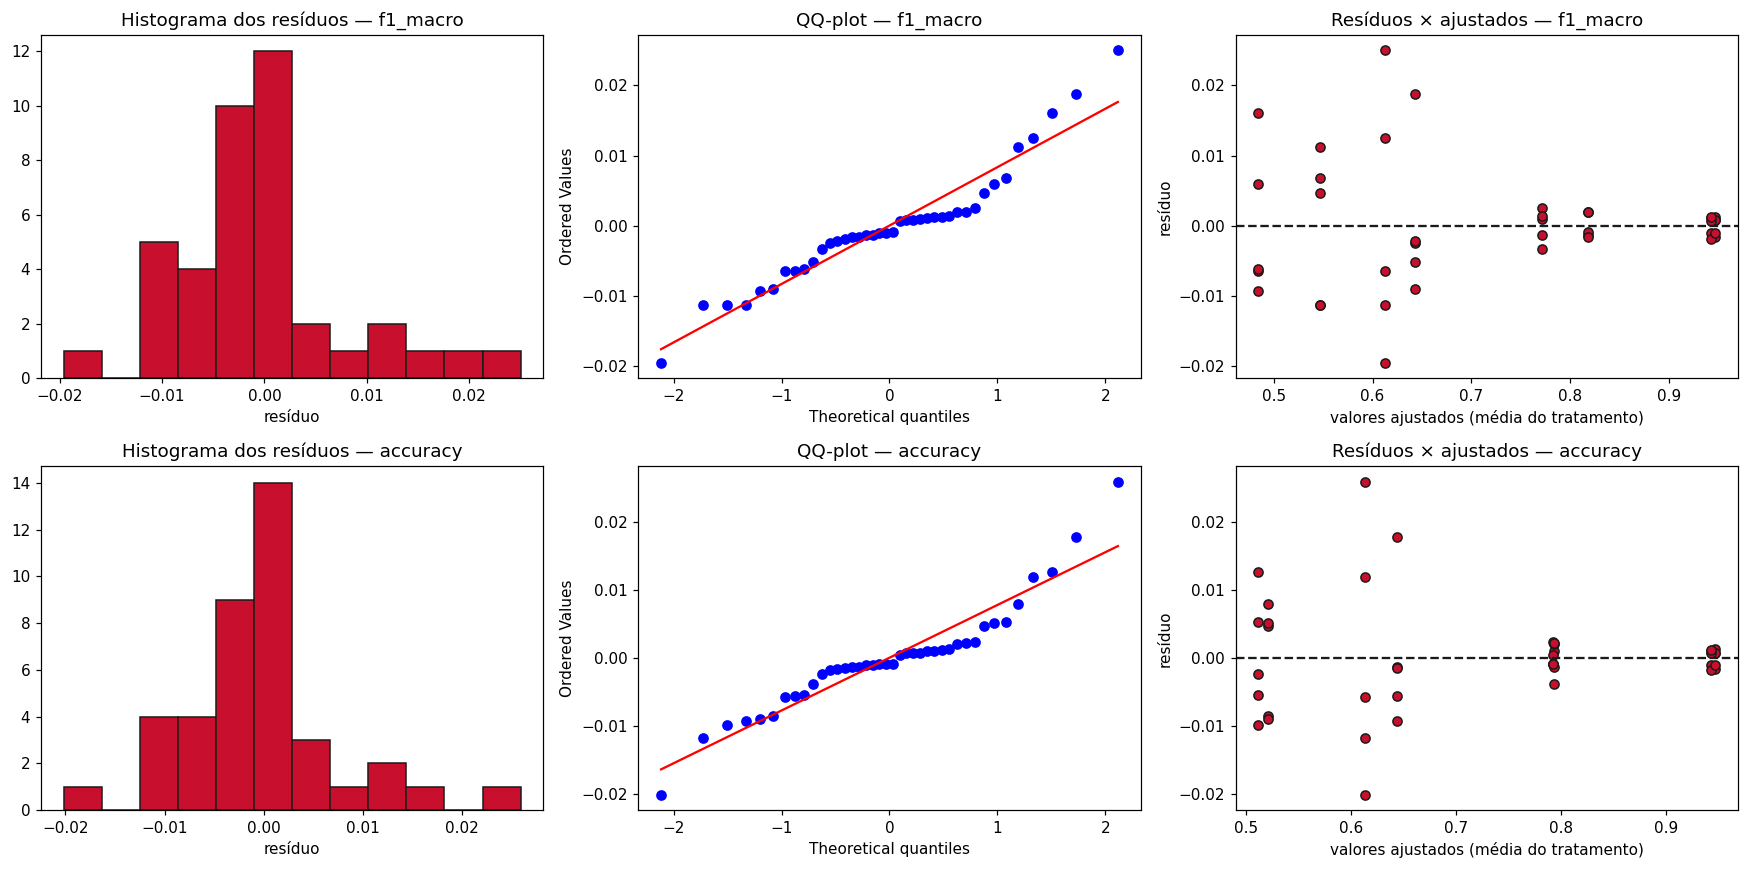

Reteste após transformação logit da resposta:


,resposta,Shapiro_W,Shapiro_p,normal_ok(5%),Levene_p,Bartlett_p,homoced_ok(5%),Durbin_Watson
0,f1_logit,0.9633,0.2175,True,0.2870,0.0111,True,1.7590
1,acc_logit,0.9549,0.1114,True,0.1596,0.0056,True,1.7084


In [9]:
# ===== Premissas do modelo fatorial 2³ — análise de resíduos =====
# Resíduo e_ij = y_ij - média do tratamento (8 tratamentos × 5 réplicas = 40 obs.)

def _residuos(data, response):
    d = data.copy()
    d["_fitted"] = d.groupby("tratamento")[response].transform("mean")
    d["_resid"] = d[response] - d["_fitted"]
    return d


def testar_premissas(data, response):
    d = _residuos(data, response)
    resid = d["_resid"].to_numpy()
    W, p_shapiro = stats.shapiro(resid)                        # normalidade
    grupos = [g[response].to_numpy() for _, g in d.groupby("tratamento")]
    _, p_levene = stats.levene(*grupos, center="median")      # homoced. (robusto)
    _, p_bartlett = stats.bartlett(*grupos)                   # homoced. (assume normal)
    dw = np.sum(np.diff(resid) ** 2) / np.sum(resid ** 2)     # independência
    return {
        "resposta": response,
        "Shapiro_W": W, "Shapiro_p": p_shapiro, "normal_ok(5%)": p_shapiro >= 0.05,
        "Levene_p": p_levene, "Bartlett_p": p_bartlett, "homoced_ok(5%)": p_levene >= 0.05,
        "Durbin_Watson": dw,
    }


premissas = pd.DataFrame([testar_premissas(df_results, r) for r in ["f1_macro", "accuracy"]])
print("Testes de premissas (resíduos do fatorial 2³):")
display(premissas)


# ---- Gráficos de diagnóstico dos resíduos ----
def plot_residuos(data, response, axes):
    d = _residuos(data, response)
    resid = d["_resid"].to_numpy(); fitted = d["_fitted"].to_numpy()
    axes[0].hist(resid, bins=12, color="#C8102E", edgecolor="#1A1A1A")
    axes[0].set_title(f"Histograma dos resíduos — {response}"); axes[0].set_xlabel("resíduo")
    stats.probplot(resid, dist="norm", plot=axes[1])
    axes[1].set_title(f"QQ-plot — {response}")
    axes[2].scatter(fitted, resid, color="#C8102E", edgecolor="#1A1A1A")
    axes[2].axhline(0, color="#1A1A1A", ls="--")
    axes[2].set_xlabel("valores ajustados (média do tratamento)")
    axes[2].set_ylabel("resíduo"); axes[2].set_title(f"Resíduos × ajustados — {response}")


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
plot_residuos(df_results, "f1_macro", axes[0])
plot_residuos(df_results, "accuracy", axes[1])
plt.tight_layout(); plt.show()


# ---- Remédio: se a homoscedasticidade falhar, transformar (logit) e retestar ----
def _logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

_dlog = df_results.copy()
_dlog["f1_logit"] = _logit(_dlog["f1_macro"])
_dlog["acc_logit"] = _logit(_dlog["accuracy"])
print("Reteste após transformação logit da resposta:")
display(pd.DataFrame([testar_premissas(_dlog, "f1_logit"),
                      testar_premissas(_dlog, "acc_logit")]))

## 9) Análise fatorial 2³ — Resposta = **F1 Macro**

In [10]:
res_f1 = factorial_2k_analysis(df_results, "f1_macro", FACTORS)
print(f"s²_e = {res_f1['s2e']:.6e}   s_q = {res_f1['s_q']:.6e}   "
      f"g.l. erro = {res_f1['df_err']}   t_crit(5%) = {res_f1['t_crit']:.4f}")

s²_e = 8.651615e-05   s_q = 1.470681e-03   g.l. erro = 32   t_crit(5%) = 2.0369


### Tabela 2 — Médias dos 8 tratamentos (F1)

In [11]:
res_f1["means"]

,tratamento,B,C,D,media,std,var,n
0,(1),-1,-1,-1,0.6432,0.0109,0.0001,5
1,b,1,-1,-1,0.4845,0.0107,0.0001,5
2,bc,1,1,-1,0.7711,0.0023,0.0000,5
3,bcd,1,1,1,0.8176,0.0018,0.0000,5
4,bd,1,-1,1,0.5469,0.0106,0.0001,5
5,c,-1,1,-1,0.9464,0.0013,0.0000,5
6,cd,-1,1,1,0.9420,0.0014,0.0000,5
7,d,-1,-1,1,0.6127,0.0183,0.0003,5


### Tabela 3 — Efeitos fatoriais (F1)

In [12]:
res_f1["effects"]

,efeito,q,efeito (2q),% variação
0,B,-0.0655,-0.1310,15.8927
1,C,0.1487,0.2975,81.9034
2,D,0.0092,0.0185,0.3161
3,BC,-0.0094,-0.0188,0.3272
4,BD,0.0180,0.0359,1.1952
5,CD,0.0013,0.0026,0.0062
6,BCD,-0.0053,-0.0105,0.1030


### Tabela 4 — Significância estatística (F1)

In [13]:
res_f1["significance"]

,efeito,q,efeito (2q),IC q low,IC q high,t,p_value,signif. (5%),SS,% variação
0,B,-0.0655,-0.1310,-0.0685,-0.0625,-44.5476,0.0000,True,0.1717,15.8927
1,C,0.1487,0.2975,0.1457,0.1517,101.1292,0.0000,True,0.8848,81.9034
2,D,0.0092,0.0185,0.0062,0.0122,6.2827,0.0000,True,0.0034,0.3161
3,BC,-0.0094,-0.0188,-0.0124,-0.0064,-6.3918,0.0000,True,0.0035,0.3272
4,BD,0.0180,0.0359,0.0150,0.0210,12.2166,0.0000,True,0.0129,1.1952
5,CD,0.0013,0.0026,-0.0017,0.0043,0.8767,0.3872,False,0.0001,0.0062
6,BCD,-0.0053,-0.0105,-0.0083,-0.0023,-3.5854,0.0011,True,0.0011,0.1030


### Decomposição da variação (F1)

In [14]:
res_f1["ss_table"]

,componente,SS,g.l.,% variação
0,B,0.1717,1,15.8927
1,C,0.8848,1,81.9034
2,D,0.0034,1,0.3161
3,BC,0.0035,1,0.3272
4,BD,0.0129,1,1.1952
5,CD,0.0001,1,0.0062
6,BCD,0.0011,1,0.1030
7,Erro,0.0028,32,0.2563
8,Total,1.0803,39,100.0000


### Gráficos — F1 Macro

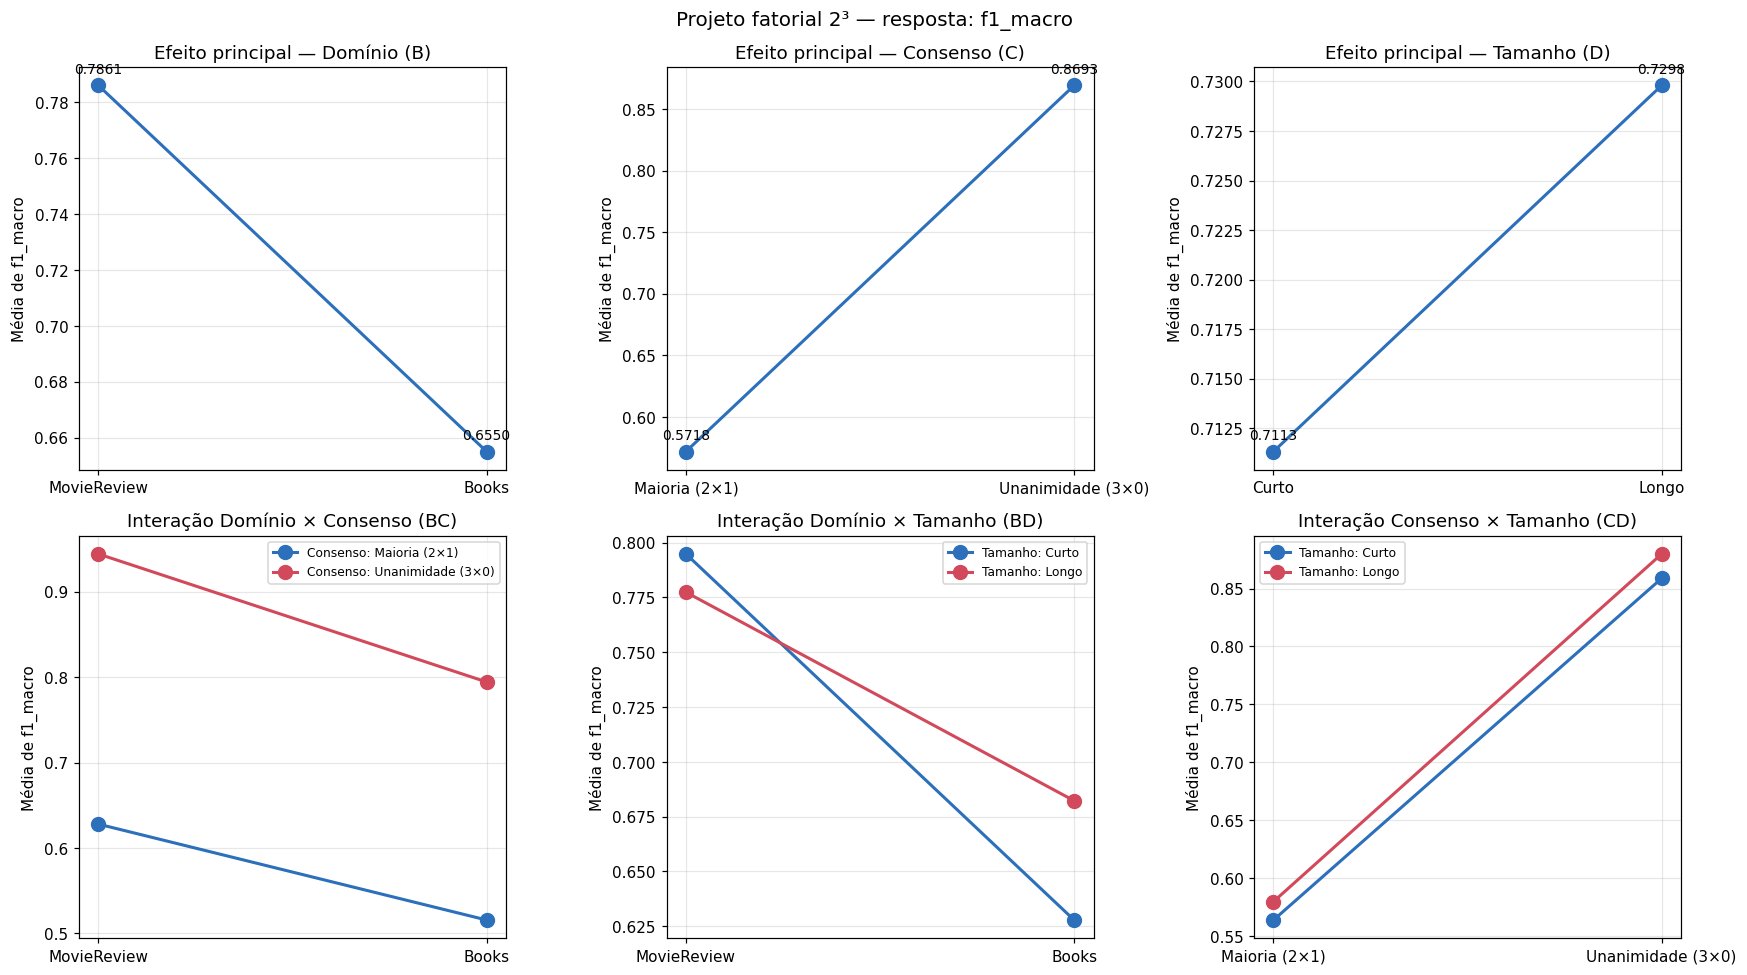

In [15]:
plot_factorial(df_results, "f1_macro")

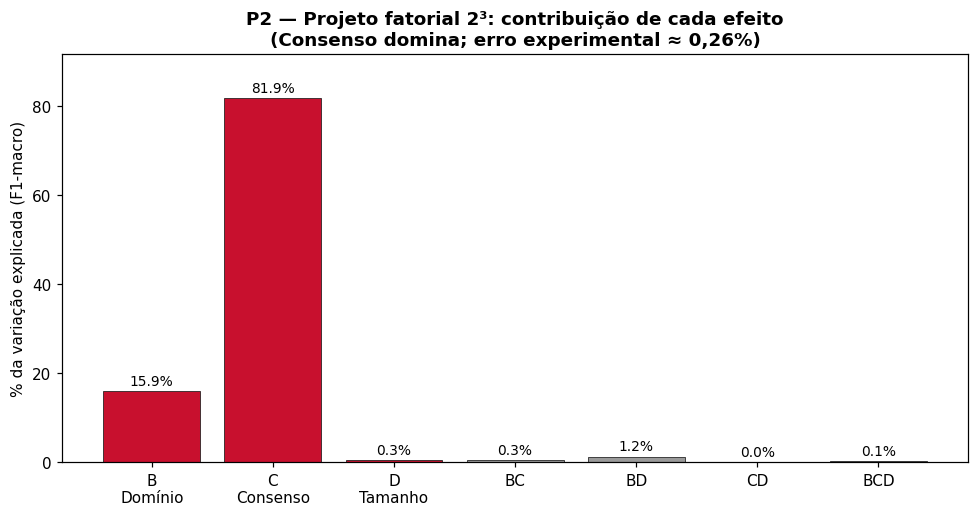

In [16]:
# === Figura P2 (tema UFMG) — % de variação por efeito (F1 macro); salva PNG ===
from pathlib import Path as _Path
_FIG = ROOT / "src" / "notebooks" / "mq" / "figuras"
_FIG.mkdir(parents=True, exist_ok=True)
_RED, _GRAY, _BLACK = "#C8102E", "#9A9A9A", "#1A1A1A"

_sig = res_f1["significance"]
_efs = _sig["efeito"].tolist()
_pvar = _sig["% variação"].tolist()
_nome = {"B": "B\nDomínio", "C": "C\nConsenso", "D": "D\nTamanho"}
_labels = [_nome.get(e, e) for e in _efs]
_cores = [_RED if e in ("B", "C", "D") else _GRAY for e in _efs]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(range(len(_efs)), _pvar, color=_cores, edgecolor=_BLACK, linewidth=0.5)
for i, v in enumerate(_pvar):
    ax.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 4),
                ha="center", fontsize=9)
ax.set_xticks(range(len(_efs)))
ax.set_xticklabels(_labels)
ax.set_ylabel("% da variação explicada (F1-macro)")
ax.set_title("P2 — Projeto fatorial 2³: contribuição de cada efeito\n"
             "(Consenso domina; erro experimental ≈ 0,26%)", fontweight="bold")
ax.set_ylim(0, max(_pvar) * 1.12)
plt.tight_layout()
fig.savefig(_FIG / "P2_variacao_fatorial.png", bbox_inches="tight")
plt.show()

## 10) Análise fatorial 2³ — Resposta = **Acurácia**

In [17]:
res_acc = factorial_2k_analysis(df_results, "accuracy", FACTORS)
print(f"s²_e = {res_acc['s2e']:.6e}   s_q = {res_acc['s_q']:.6e}   "
      f"g.l. erro = {res_acc['df_err']}   t_crit(5%) = {res_acc['t_crit']:.4f}")

s²_e = 7.685685e-05   s_q = 1.386153e-03   g.l. erro = 32   t_crit(5%) = 2.0369


### Médias dos 8 tratamentos (Acurácia)

In [18]:
res_acc["means"]

,tratamento,B,C,D,media,std,var,n
0,(1),-1,-1,-1,0.6443,0.0105,0.0001,5
1,b,1,-1,-1,0.5120,0.0089,0.0001,5
2,bc,1,1,-1,0.7931,0.0026,0.0000,5
3,bcd,1,1,1,0.7922,0.0014,0.0000,5
4,bd,1,-1,1,0.5214,0.0081,0.0001,5
5,c,-1,1,-1,0.9464,0.0013,0.0000,5
6,cd,-1,1,1,0.9420,0.0014,0.0000,5
7,d,-1,-1,1,0.6136,0.0186,0.0003,5


### Efeitos fatoriais (Acurácia)

In [19]:
res_acc["effects"]

,efeito,q,efeito (2q),% variação
0,B,-0.0660,-0.1319,16.4651
1,C,0.1478,0.2956,82.6878
2,D,-0.0033,-0.0066,0.0417
3,BC,-0.0098,-0.0197,0.3661
4,BD,0.0054,0.0109,0.1122
5,CD,0.0020,0.0040,0.0152
6,BCD,-0.0046,-0.0092,0.0792


### Significância estatística (Acurácia)

In [20]:
res_acc["significance"]

,efeito,q,efeito (2q),IC q low,IC q high,t,p_value,signif. (5%),SS,% variação
0,B,-0.0660,-0.1319,-0.0688,-0.0631,-47.5825,0.0000,True,0.1740,16.4651
1,C,0.1478,0.2956,0.1450,0.1506,106.6317,0.0000,True,0.8739,82.6878
2,D,-0.0033,-0.0066,-0.0061,-0.0005,-2.3953,0.0226,True,0.0004,0.0417
3,BC,-0.0098,-0.0197,-0.0127,-0.0070,-7.0949,0.0000,True,0.0039,0.3661
4,BD,0.0054,0.0109,0.0026,0.0083,3.9273,0.0004,True,0.0012,0.1122
5,CD,0.0020,0.0040,-0.0008,0.0048,1.4450,0.1582,False,0.0002,0.0152
6,BCD,-0.0046,-0.0092,-0.0074,-0.0018,-3.3009,0.0024,True,0.0008,0.0792


### Decomposição da variação (Acurácia)

In [21]:
res_acc["ss_table"]

,componente,SS,g.l.,% variação
0,B,0.1740,1,16.4651
1,C,0.8739,1,82.6878
2,D,0.0004,1,0.0417
3,BC,0.0039,1,0.3661
4,BD,0.0012,1,0.1122
5,CD,0.0002,1,0.0152
6,BCD,0.0008,1,0.0792
7,Erro,0.0025,32,0.2327
8,Total,1.0569,39,100.0000


### Gráficos — Acurácia

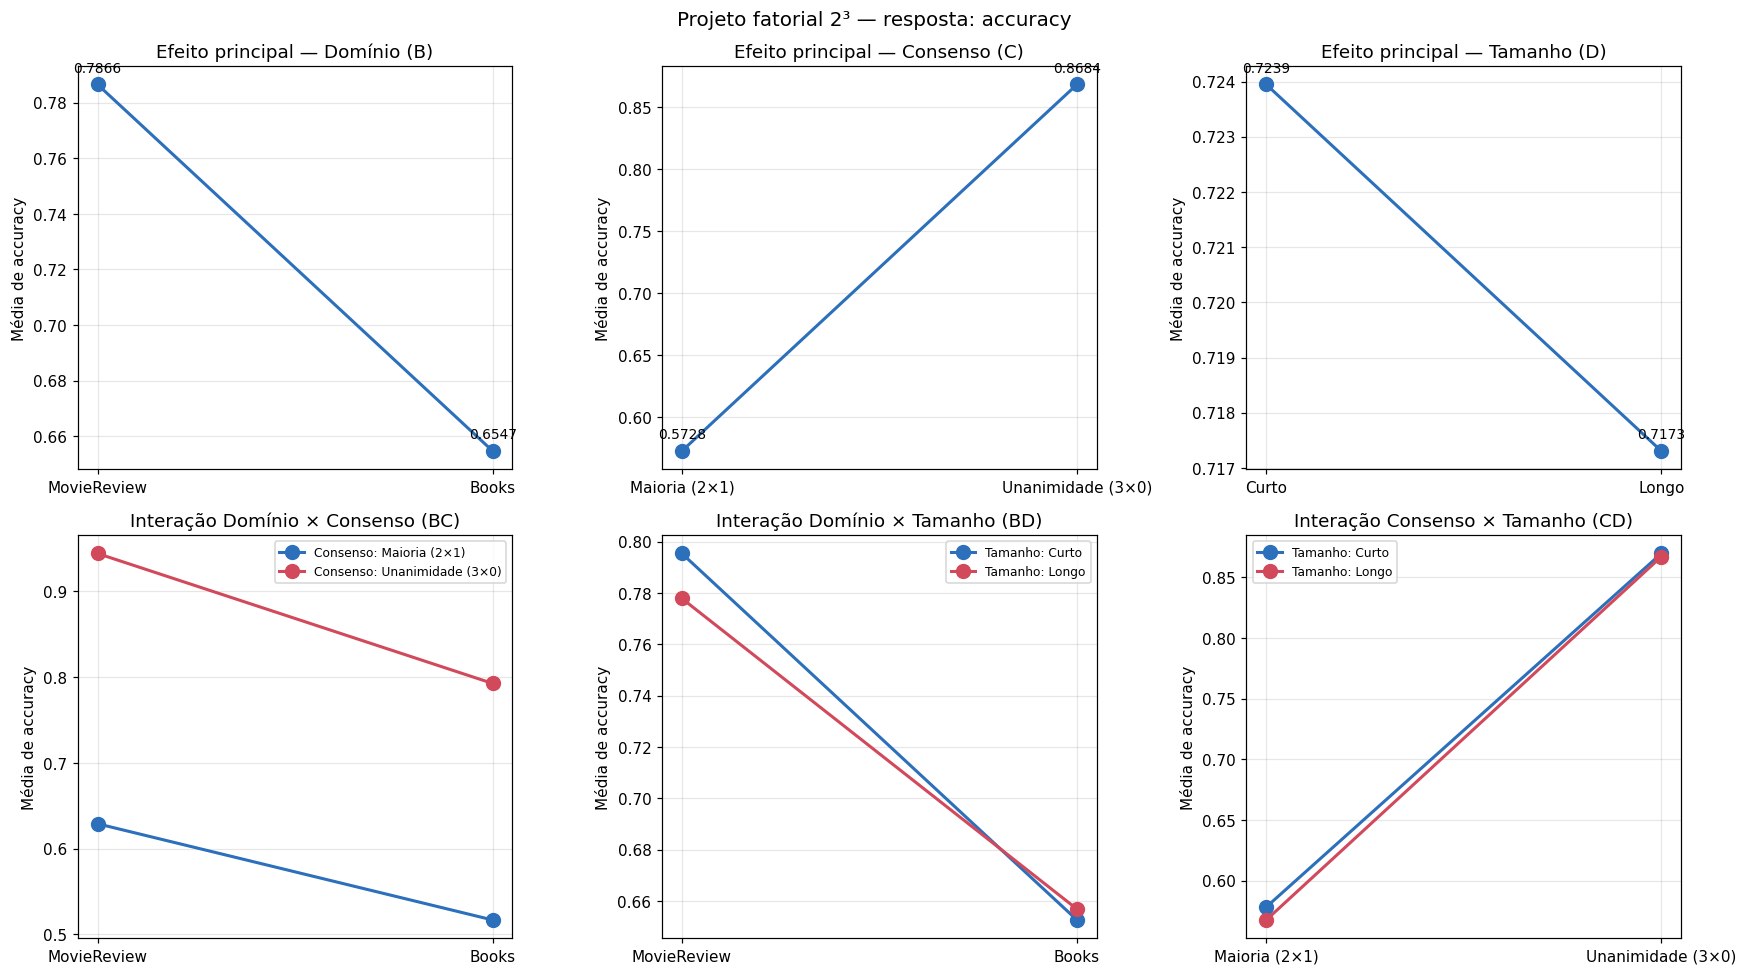

In [22]:
plot_factorial(df_results, "accuracy")

## 11) Análise de efeitos sobre **logit(F1)** (pressupostos atendidos)

O §8 mostrou que o F1 original **viola** normalidade e homoscedasticidade, mas
**logit(F1) atende ambas**. Reaplicamos aqui a análise de efeitos sobre logit(F1) **e logit(Acurácia)**,
de modo que os **p-valores passam a ser estatisticamente válidos**.

> Os **efeitos (2q) ficam em escala logit** (não em pontos de F1). A comparação
> direta com a análise no F1 original é feita pela **% de variação** e pela
> **significância** — que devem se manter (Consenso ≫ Domínio).

In [23]:
# Análise de efeitos sobre logit(F1) — pressupostos agora atendidos (normalidade + variância)
df_results["f1_logit"] = _logit(df_results["f1_macro"])
res_f1_logit = factorial_2k_analysis(df_results, "f1_logit", FACTORS)
print(f"logit(F1):  s²_e = {res_f1_logit['s2e']:.4e}   "
      f"erro = {100 * res_f1_logit['SSE'] / res_f1_logit['SST']:.3f}% da variação   "
      f"t_crit(5%) = {res_f1_logit['t_crit']:.4f}")

print("\nSignificância dos efeitos sobre logit(F1) — p-valores agora válidos:")
display(res_f1_logit["significance"][["efeito", "efeito (2q)", "p_value", "signif. (5%)", "% variação"]])

print("Comparação da % de variação: F1 original × logit(F1)")
_cmp = res_f1["effects"][["efeito", "% variação"]].rename(columns={"% variação": "%var_F1_original"})
_cmp["%var_logit(F1)"] = res_f1_logit["effects"]["% variação"].values
display(_cmp.round(2))

logit(F1):  s²_e = 1.6893e-03   erro = 0.121% da variação   t_crit(5%) = 2.0369

Significância dos efeitos sobre logit(F1) — p-valores agora válidos:


,efeito,efeito (2q),p_value,signif. (5%),% variação
0,B,-0.9667,0.0000,True,20.8738
1,C,1.7998,0.0000,True,72.3613
2,D,0.0807,0.0000,True,0.1453
3,BC,-0.5054,0.0000,True,5.7068
4,BD,0.1871,0.0000,True,0.7820
5,CD,0.0209,0.1177,False,0.0098
6,BCD,-0.0033,0.7997,False,0.0002


Comparação da % de variação: F1 original × logit(F1)


,efeito,%var_F1_original,%var_logit(F1)
0,B,15.8900,20.8700
1,C,81.9000,72.3600
2,D,0.3200,0.1500
3,BC,0.3300,5.7100
4,BD,1.2000,0.7800
5,CD,0.0100,0.0100
6,BCD,0.1000,0.0000


In [24]:
# Mesmo para a Acuracia: efeitos sobre logit(acuracia) — pressupostos atendidos
df_results["acc_logit"] = _logit(df_results["accuracy"])
res_acc_logit = factorial_2k_analysis(df_results, "acc_logit", FACTORS)
print(f"logit(Acc):  s2_e = {res_acc_logit['s2e']:.4e}   "
      f"erro = {100 * res_acc_logit['SSE'] / res_acc_logit['SST']:.3f}% da variacao   "
      f"t_crit(5%) = {res_acc_logit['t_crit']:.4f}")
print()
print("Significancia dos efeitos sobre logit(Acuracia) — p-valores agora validos:")
display(res_acc_logit["significance"][["efeito", "efeito (2q)", "p_value", "signif. (5%)", "% variação"]])
print("Comparacao da % de variacao: Acuracia original x logit(Acuracia)")
_cmpa = res_acc["effects"][["efeito", "% variação"]].rename(columns={"% variação": "%var_Acc_original"})
_cmpa["%var_logit(Acc)"] = res_acc_logit["effects"]["% variação"].values
display(_cmpa.round(2))

logit(Acc):  s2_e = 1.5324e-03   erro = 0.111% da variacao   t_crit(5%) = 2.0369

Significancia dos efeitos sobre logit(Acuracia) — p-valores agora validos:


,efeito,efeito (2q),p_value,signif. (5%),% variação
0,B,-0.9754,0.0000,True,21.5136
1,C,1.7878,0.0000,True,72.2660
2,D,-0.0455,0.0009,True,0.0469
3,BC,-0.5136,0.0000,True,5.9650
4,BD,0.0616,0.0000,True,0.0858
5,CD,0.0013,0.9194,False,0.0000
6,BCD,-0.0228,0.0745,False,0.0118


Comparacao da % de variacao: Acuracia original x logit(Acuracia)


,efeito,%var_Acc_original,%var_logit(Acc)
0,B,16.4700,21.5100
1,C,82.6900,72.2700
2,D,0.0400,0.0500
3,BC,0.3700,5.9600
4,BD,0.1100,0.0900
5,CD,0.0200,0.0000
6,BCD,0.0800,0.0100


## 12) Resumo / interpretação

- **B (Domínio)**, **C (Consenso)** e **D (Tamanho)** são os efeitos principais.
- **BC, BD, CD, BCD** são as interações — em especial **BD** (o efeito do tamanho
  depende do domínio?) e **CD** (o tamanho importa mais sob maioria ou
  unanimidade?).
- Leia pelo **tamanho do efeito (2q)** e pela **% de variação**: o erro
  experimental é ínfimo, então o p-valor satura em "significativo".
- A linha **Erro** das tabelas de decomposição mostra a % de variação residual.
- **Validade estatística:** os p-valores no espaço original do F1 são questionáveis
  (premissas violadas, §8); a análise sobre **logit(F1)** (§11) atende os
  pressupostos e confirma as mesmas conclusões (Consenso ≫ Domínio).

In [25]:
def resumo(res, titulo):
    err_pct = 100 * res["SSE"] / res["SST"]
    print(f"=== RESUMO {titulo} ===")
    cols = ["efeito", "efeito (2q)", "t", "p_value", "signif. (5%)", "% variação"]
    print(res["significance"][cols].to_string(index=False))
    print(f"\nErro experimental: s²_e = {res['s2e']:.3e} | "
          f"SSE = {res['SSE']:.6f} | % variação (erro) = {err_pct:.4f}%")


resumo(res_f1, "F1 MACRO")
print()
resumo(res_acc, "ACURÁCIA")

=== RESUMO F1 MACRO ===
efeito  efeito (2q)        t  p_value  signif. (5%)  % variação
     B      -0.1310 -44.5476   0.0000          True     15.8927
     C       0.2975 101.1292   0.0000          True     81.9034
     D       0.0185   6.2827   0.0000          True      0.3161
    BC      -0.0188  -6.3918   0.0000          True      0.3272
    BD       0.0359  12.2166   0.0000          True      1.1952
    CD       0.0026   0.8767   0.3872         False      0.0062
   BCD      -0.0105  -3.5854   0.0011          True      0.1030

Erro experimental: s²_e = 8.652e-05 | SSE = 0.002769 | % variação (erro) = 0.2563%

=== RESUMO ACURÁCIA ===
efeito  efeito (2q)        t  p_value  signif. (5%)  % variação
     B      -0.1319 -47.5825   0.0000          True     16.4651
     C       0.2956 106.6317   0.0000          True     82.6878
     D      -0.0066  -2.3953   0.0226          True      0.0417
    BC      -0.0197  -7.0949   0.0000          True      0.3661
    BD       0.0109   3.9273   0.00

In [26]:
# ===== Exportar análises em .json (data/results/mq/fatorial_2x2x2) =====
import json

EXPORT_DIR = ROOT / "data" / "results" / "mq" / "fatorial_2x2x2"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _to_jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.to_dict(orient="records")
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, dict):
        return {k: _to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_to_jsonable(v) for v in o]
    return o


payload = {
    "design": "2^3 (B=domínio, C=consenso, D=tamanho do texto)",
    "fatores": {
        "B": {"-1": "movie_review", "+1": "books"},
        "C": {"-1": "2x1 (maioria)", "+1": "3x0 (unanimidade)"},
        "D": {"-1": "curto", "+1": "longo"},
    },
    "n_replicas": N_REPS,
    "premissas": _to_jsonable(premissas),
    "resultados_por_celula": _to_jsonable(df_results),
    "analise": {
        "f1_macro": _to_jsonable(res_f1),
        "accuracy": _to_jsonable(res_acc),
        "f1_logit": _to_jsonable(res_f1_logit),   # análise com pressupostos atendidos
        "acc_logit": _to_jsonable(res_acc_logit),
    },
}

with open(EXPORT_DIR / "analise_fatorial_2x2x2.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
with open(EXPORT_DIR / "resultados_por_celula.json", "w", encoding="utf-8") as f:
    json.dump(_to_jsonable(df_results), f, ensure_ascii=False, indent=2)

print("✓ Análises salvas em:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*.json")):
    print("  -", p.name)

✓ Análises salvas em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\fatorial_2x2x2
  - analise_fatorial_2x2x2.json
  - resultados_por_celula.json
